# 서울시 100m 격자 문화누리 대상인구 추정

## 목적
- 행정동별 기초생활수급자와 차상위계층을 문화누리 대상인구로 정의
- 행정동 총량을 100m 격자의 추정인구와 공시지가에 따라 배분
- 공시지가 반영 강도를 역검정하고 최종 beta=1 적용

In [1]:
import pathlib
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["font.family"] = "Noto Sans KR"
plt.rcParams["axes.unicode_minus"] = False

## 경로 설정

In [2]:
BASE_PATH = pathlib.Path.cwd().resolve()
if not (BASE_PATH / "data").exists():
    BASE_PATH = next(p for p in BASE_PATH.parents if (p / "data").exists())

RAW_PATH = BASE_PATH / "data" / "raw"
PROCESSED_PATH = BASE_PATH / "data" / "processed"
WELFARE_PATH = RAW_PATH / "population" / "demographics" / "welfare"
DEMOGRAPHICS_PATH = RAW_PATH / "population" / "demographics" / "source"
LAND_PATH = RAW_PATH / "spatial" / "grid" / "land_value"
POPULATION_FILE = PROCESSED_PATH / "estimated_population" / "서울시_100m_추정인구.gpkg"
OUTPUT_PATH = PROCESSED_PATH / "estimated_target_population"
OUTPUT_FILE = OUTPUT_PATH / "서울시_100m_문화누리추정인구수.gpkg"
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

## 행정동별 문화누리 대상인구 생성

In [3]:
basic_source = pd.read_csv(
    WELFARE_PATH / "seoul_basic_livelihood_recipients_2023.csv",
    encoding="utf-8",
)
basic = basic_source[["동별(1)", "동별(2)", "2023.2"]].copy()
basic.columns = ["시군구", "행정동", "기초생활수급자수"]
basic = basic.iloc[3:]
basic = basic.loc[
    ~basic["시군구"].isin(["합계", "본청"])
    & ~basic["행정동"].isin(["소계", "기타"])
].copy()
basic["기초생활수급자수"] = (
    basic["기초생활수급자수"].replace("-", np.nan).fillna(0).astype(int)
)
basic["행정동"] = basic["행정동"].replace({
    "종로1.2.3.4가동":"종로1·2·3·4가동", "종로5.6가동":"종로5·6가동",
    "금호2.3가동":"금호2·3가동", "면목3.8동":"면목3·8동",
    "중계2.3동":"중계2·3동", "상계3.4동":"상계3·4동",
    "상계6.7동":"상계6·7동",
})
basic = basic.groupby(["시군구","행정동"],as_index=False)["기초생활수급자수"].sum()

near = pd.read_csv(
    WELFARE_PATH / "seoul_near_poverty_by_age_dong_20210731.csv",
    encoding="cp949",
)
near = near.groupby(["시군구","읍면동","연령구간"],as_index=False)["수급권자수"].sum()
near = near.rename(columns={"읍면동":"행정동","수급권자수":"차상위계층수급권자수"})
near["행정동"] = near["행정동"].replace({
    "강남구":np.nan,"강동구":np.nan,"강북구":np.nan,"구로구":np.nan,"성동구":np.nan,
    "일원2동":"개포3동","상일동":"상일1동","상일제1동":"상일1동","상일제2동":"상일2동",
    "번제1동":"번1동","번제2동":"번2동","번제3동":"번3동",
    "수유제1동":"수유1동","수유제2동":"수유2동","자양제4동":"자양4동","길음제2동":"길음2동",
    "금호2-3가동":"금호2·3가동","면목제3.8동":"면목3·8동","중계2,3동":"중계2·3동",
    "종로1.2.3.4가동":"종로1·2·3·4가동","종로5.6가동":"종로5·6가동",
    "상계3.4동":"상계3·4동","상계6동":"상계6·7동","상계7동":"상계6·7동",
    "상계6.7동":"상계6·7동",
    **{f"상계{i}동":"상계10동" for i in range(11,24)},
})
near = near.loc[near["행정동"].notna()]
near = near.groupby(["시군구","행정동"],as_index=False)["차상위계층수급권자수"].sum()

assert POPULATION_FILE.exists(), "2번 노트북 결과가 없습니다."
grid = gpd.read_file(POPULATION_FILE)
dong = grid[["시군구","행정동"]].drop_duplicates()
target = dong.merge(basic,on=["시군구","행정동"],how="left",validate="one_to_one")
target = target.merge(near,on=["시군구","행정동"],how="left",validate="one_to_one")
display(target[target.isna().any(axis=1)])
assert target.isna().sum().sum() == 0
target["문화누리대상자"] = target["기초생활수급자수"] + target["차상위계층수급권자수"]

display(pd.Series({
    "행정동 수":len(target),
    "기초생활수급자 합계":int(target["기초생활수급자수"].sum()),
    "차상위계층 합계":int(target["차상위계층수급권자수"].sum()),
    "문화누리 대상인구 합계":int(target["문화누리대상자"].sum()),
},name="확인값").to_frame())

,시군구,행정동,기초생활수급자수,차상위계층수급권자수


,확인값
행정동 수,426
기초생활수급자 합계,417593
차상위계층 합계,164956
문화누리 대상인구 합계,582549


## 공시지가 결합과 결측 처리

In [4]:
land_files=sorted(LAND_PATH.glob("*/vl_blk.shp"))
assert land_files, "공시지가 파일이 없습니다."
frames=[]
for path in land_files:
    frame=gpd.read_file(path,encoding="utf-8-sig")
    frames.append(frame[["gid","val"]])
land=pd.concat(frames,ignore_index=True).rename(columns={"gid":"GRID_CD","val":"공시지가"})
land=land.groupby("GRID_CD",as_index=False)["공시지가"].mean()

grid_target=grid.merge(target,on=["시군구","행정동"],how="left",validate="many_to_one")
grid_target=grid_target.merge(land,on="GRID_CD",how="left",validate="one_to_one")
missing_before=int(grid_target["공시지가"].isna().sum())
grid_target["공시지가"]=grid_target["공시지가"].fillna(
    grid_target.groupby("GRID_CD_500")["공시지가"].transform("mean")
)
missing_500=int(grid_target["공시지가"].isna().sum())
grid_target["공시지가"]=grid_target["공시지가"].fillna(
    grid_target.groupby(["시군구","행정동"])["공시지가"].transform("mean")
)
missing_dong=int(grid_target["공시지가"].isna().sum())

display(pd.Series({
    "최초 결측":missing_before,
    "500m 평균 보정 후":missing_500,
    "행정동 평균 보정 후":missing_dong,
    "격자 중복":int(grid_target["GRID_CD"].duplicated().sum()),
},name="확인값").to_frame())
assert missing_dong==0

,확인값
최초 결측,16534
500m 평균 보정 후,2022
행정동 평균 보정 후,0
격자 중복,0


## 공시지가 반영 강도 역검정

,모형,MAE,RMSE,WAPE,MAPE
0,인구비율모형,551.0795,796.5916,0.4030,1.4582
1,공시지가모형_0,551.2639,795.3887,0.4031,1.1242
2,공시지가모형_0.25,537.1933,779.7014,0.3928,1.0887
3,공시지가모형_0.5,526.0492,766.2301,0.3847,1.0580
4,공시지가모형_0.75,517.0641,755.0560,0.3781,1.0317
5,공시지가모형_1.0,510.0137,746.3066,0.3730,1.0098


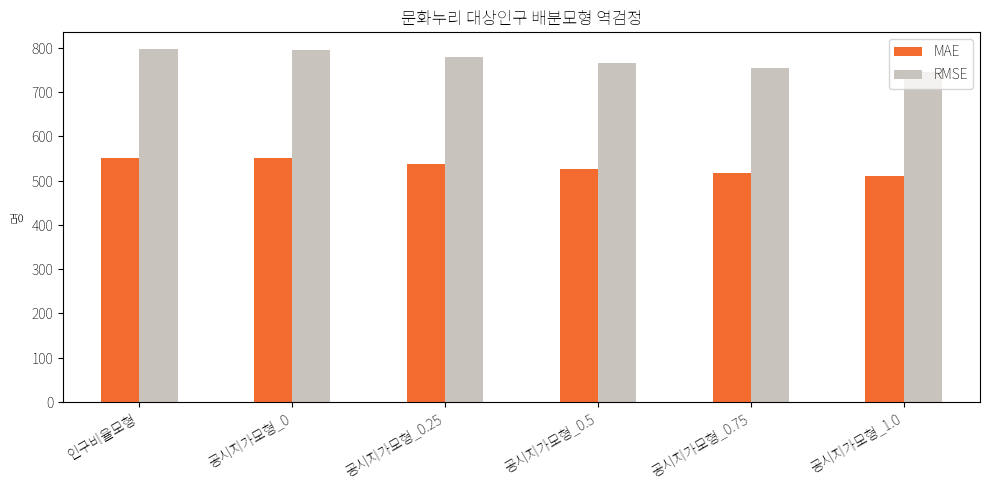

In [5]:
dong_population=pd.read_csv(
    DEMOGRAPHICS_PATH/"서울시_행정동별_인구수_2024.csv",encoding="utf-8-sig"
)
grid_target=grid_target.merge(
    dong_population,on=["시군구","행정동"],how="left",validate="many_to_one"
)
assert grid_target["행정동별_인구수"].isna().sum()==0

valid=(grid_target["공시지가"]>0)&(grid_target["추정_인구수"]>0)
land_reference=grid_target.loc[valid,"공시지가"].median()
grid_target["로그상대공시지가"]=np.log1p(grid_target["공시지가"]/land_reference)

keys=["시군구","행정동"]
actual=grid_target.groupby(keys,as_index=False).agg(
    실제_대상자=("문화누리대상자","first"),
    행정동인구=("행정동별_인구수","first"),
)
gu=actual.groupby("시군구",as_index=False).agg(
    구_대상자=("실제_대상자","sum"),구_인구=("행정동인구","sum")
)
test=actual.merge(gu,on="시군구",validate="many_to_one")
test["인구비율모형"]=test["행정동인구"]*test["구_대상자"]/test["구_인구"]
predictions=["인구비율모형"]

for beta in [0,0.25,0.5,0.75,1.0]:
    score=f"점수_{beta}"
    dong_score=f"동점수_{beta}"
    pred=f"공시지가모형_{beta}"
    grid_target[score]=grid_target["추정_인구수"]*np.exp(
        -beta*grid_target["로그상대공시지가"]
    )
    by_dong=grid_target.groupby(keys,as_index=False)[score].sum().rename(columns={score:dong_score})
    test=test.merge(by_dong,on=keys,validate="one_to_one")
    gu_score=test.groupby("시군구")[dong_score].transform("sum")
    test[pred]=test["구_대상자"]*test[dong_score]/gu_score
    predictions.append(pred)

rows=[]
for pred in predictions:
    error=test["실제_대상자"]-test[pred]
    absolute=error.abs()
    rows.append({
        "모형":pred,"MAE":absolute.mean(),"RMSE":np.sqrt((error**2).mean()),
        "WAPE":absolute.sum()/test["실제_대상자"].sum(),
        "MAPE":(absolute/test["실제_대상자"]).mean(),
    })
metric_table=pd.DataFrame(rows)
display(metric_table.round(4))

metric_table.set_index("모형")[["MAE","RMSE"]].plot(
    kind="bar",figsize=(10,5),color=["#F46B2F","#C9C3BE"]
)
plt.title("문화누리 대상인구 배분모형 역검정")
plt.xlabel("")
plt.ylabel("명")
plt.xticks(rotation=30,ha="right")
plt.tight_layout()
plt.show()

## 최종 격자 배분과 품질 점검

In [6]:
beta=1.0
grid_target["배분점수"]=grid_target["추정_인구수"]*np.exp(
    -beta*grid_target["로그상대공시지가"]
)
grid_target["행정동_점수합"]=grid_target.groupby(keys)["배분점수"].transform("sum")
grid_target["격자_배분비율"]=grid_target["배분점수"]/grid_target["행정동_점수합"]
grid_target["문화누리대상자_추정_인구수"]=(
    grid_target["문화누리대상자"]*grid_target["격자_배분비율"]
)

columns=[
    "GRID_CD","행정동코드","시군구","행정동","중심점_x","중심점_y",
    "원본_인구수","주거면적","주택수","공시지가","추정_인구수",
    "문화누리대상자_추정_인구수","GRID_CD_500","geometry",
]
result=grid_target[columns].copy()

dong_check=result.groupby(keys)["문화누리대상자_추정_인구수"].sum().reset_index()
dong_check=dong_check.merge(target[keys+["문화누리대상자"]],on=keys,validate="one_to_one")
dong_check["오차"]=dong_check["문화누리대상자"]-dong_check["문화누리대상자_추정_인구수"]

check=pd.Series({
    "최종 격자 수":len(result),
    "격자 중복":int(result["GRID_CD"].duplicated().sum()),
    "전체 결측":int(result.isna().sum().sum()),
    "음수 대상인구":int((result["문화누리대상자_추정_인구수"]<0).sum()),
    "행정동별 총량 오차":float(dong_check["오차"].abs().sum()),
    "대상인구 합계":float(result["문화누리대상자_추정_인구수"].sum()),
},name="확인값")
display(check.to_frame())

assert len(result)==60528
assert check["격자 중복"]==0
assert check["전체 결측"]==0
assert check["음수 대상인구"]==0
assert np.isclose(check["행정동별 총량 오차"],0)
assert np.isclose(check["대상인구 합계"],target["문화누리대상자"].sum())

,확인값
최종 격자 수,6.052800e+04
격자 중복,0.000000e+00
전체 결측,0.000000e+00
음수 대상인구,0.000000e+00
행정동별 총량 오차,8.527401e-12
대상인구 합계,5.825490e+05


## 결과 저장 및 요약

In [7]:
if OUTPUT_FILE.exists():
    OUTPUT_FILE.unlink()
result.to_file(OUTPUT_FILE,driver="GPKG")
saved=gpd.read_file(OUTPUT_FILE)
assert len(saved)==60528
assert saved["GRID_CD"].duplicated().sum()==0
assert saved.isna().sum().sum()==0

best=metric_table.sort_values(["MAE","RMSE","WAPE","MAPE"]).iloc[0]
summary=pd.Series({
    "저장 파일":OUTPUT_FILE.name,
    "서울 100m 격자 수":f"{len(result):,}",
    "행정동 수":len(target),
    "문화누리 대상인구 합계":f"{result['문화누리대상자_추정_인구수'].sum():,.0f}명",
    "결측값":int(result.isna().sum().sum()),
    "격자 중복":int(result["GRID_CD"].duplicated().sum()),
    "행정동별 총량 오차":f"{dong_check['오차'].abs().sum():.10f}",
    "역검정 최적 모형":best["모형"],
},name="결과")
display(summary.to_frame())
print(f"저장 완료: {OUTPUT_FILE}")

,결과
저장 파일,서울시_100m_문화누리추정인구수.gpkg
서울 100m 격자 수,"60,528"
행정동 수,426
문화누리 대상인구 합계,"582,549명"
결측값,0
격자 중복,0
행정동별 총량 오차,0.0000000000
역검정 최적 모형,공시지가모형_1.0


저장 완료: C:\Users\ben20\Documents\DataScience\projects\Oracle-Project\data\processed\estimated_target_population\서울시_100m_문화누리추정인구수.gpkg
